In [18]:
import os
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from importlib import reload
import functions as fct
reload(fct)
import functions as fct

In [21]:
sargeo = pd.read_csv("excels/SARGEO_SAR_final.csv")
sar_inter = sargeo[sargeo["sar_xy"].isna()]["sar_inter"].iloc[0]
sargeo[sargeo["sar_inter"] == sar_inter]

,cyclone,canal,fichier,lat_centre,lon_centre,sar_acquisition_time,sar_xy,sar_inter,sar_path
0,al102019,IRWIN,s1a-iw-owi-cm-20190920t221952-20190920t222132-...,19.548832,298.289185,"2019-09-20T22:19:52,000",NaN,s1a-iw-owi-cm-20190920t221837-20190920t222132-...,/home/datawork-cersat-public/cache/public/ftp/...


In [39]:
sargeo = pd.read_csv("excels/SARGEO_Final.csv")   #chemin vers le csv du sargeo modifiée (liée avec le listing du sar)
sar_list_df = pd.read_csv("excels/listing_res_3km.csv")           #chemin vers le csv du listing sar
print(len(sargeo),len(sar_list_df))
sargeo.fillna(0, inplace=True)
sargeo.head(1)

1406 10296


,Unnamed: 0,cyclone,canal,fichier,lat_centre,lon_centre,sar_acquisition_time,sar_xy,sar_inter,sar_path
0,0,al102019,IRWIN,s1a-iw-owi-cm-20190920t221952-20190920t222132-...,19.853086,297.8992,"2019-09-20T22:19:52,000",0,s1a-iw-owi-cm-20190920t221837-20190920t222132-...,/home/datawork-cersat-public/cache/public/ftp/...


In [ ]:
# output_dir = "/scale/user/mtannaou/alternance/donnees_sar_changes"         #chemin d output


# for file_path in sargeo["sar_path"]: 
#     try: 
#         fct.convert_sar_to_xy(file_path, sargeo, output_dir) 
#     except Exception as e: 
#         print(f"❌ Erreur pour {file_path}: {e}")

In [41]:
sargeo.nunique()

Unnamed: 0              1406
cyclone                  302
canal                      1
fichier                 1406
lat_centre              1341
lon_centre              1341
sar_acquisition_time    1406
sar_xy                  1401
sar_inter               1389
sar_path                1389
dtype: int64

In [51]:
sargeo_update = pd.read_csv("excels/SARGEO_SAR.csv")
compt = 0
for file in os.listdir("donnees_sar_changes") : 
    file_name = file.split("_aeqd")[0]
    df_extrait = sargeo_update[sargeo_update["sar_xy"].str.contains(file_name)]
    compt += 1
print(len(sargeo_update),compt)
sargeo_update.isnull().sum()

1406 1389


Unnamed: 0              0
cyclone                 0
canal                   0
fichier                 0
lat_centre              0
lon_centre              0
sar_acquisition_time    0
sar_xy                  0
sar_inter               0
sar_path                0
dtype: int64

## Visulalisation

4 fichiers de alexis mouche a visuliser

In [48]:
indice = 2

/tmp/ipykernel_33825/3184876281.py:28: FutureWarning: In a future version, xarray will not decode the variable 'time_diff' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_sar = xr.open_dataset(path_sar_geo)


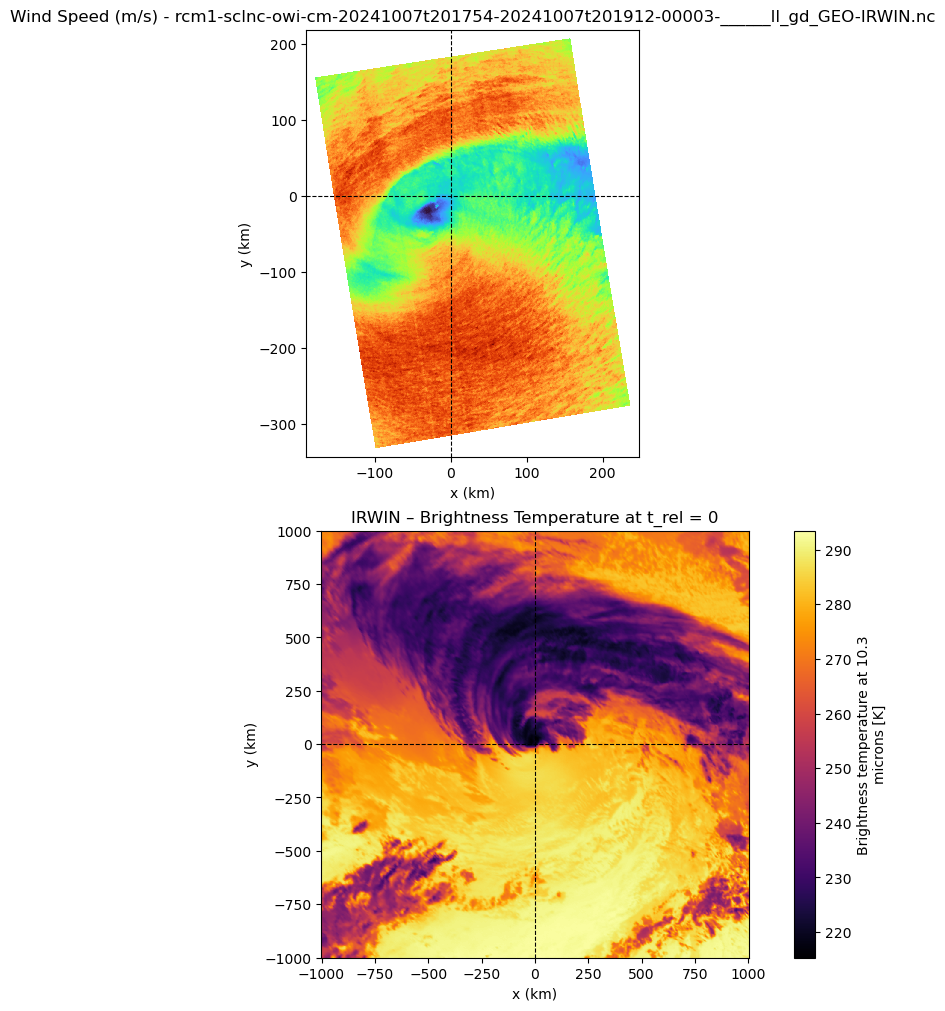

In [49]:
import os
import pandas as pd
import re
import numpy as np
# import GEO_to_XYcenter as xysar
import matplotlib.pyplot as plt
import xarray as xr


sar_listes = ['/home/datawork-cersat-public/cache/public/ftp/project/sarwing/processings/grdwind+windir_2025v6v12_2v0_0v3v9_0v0v6_0v0v6_1v4v3_1v0v15_1v0v10_1v2v5_1v2v2_1v1v1_1v2v1/cmod5n_ecmwf_norecal_rs2rcmgmfv4_28052025/rcm-1/L2M/sclnc/rcm-1_sclnc/2024/278/RCM1_OK3296938_PK3300253_1_SCLNC_20241004_212519_VV_VH_GRD/rcm1-sclnc-owi-cm-20241004t212518-20241004t212636-00003-xxxxx.nc'
,'/home/datawork-cersat-public/cache/public/ftp/project/sarwing/processings/grdwind+windir_2025v6v12_2v0_0v3v9_0v0v6_0v0v6_1v4v3_1v0v15_1v0v10_1v2v5_1v2v2_1v1v1_1v2v1/cmod5n_ecmwf_norecal_rs2rcmgmfv4_28052025/sentinel-1a/L2M/EW/S1A_EW_GRDM_1S/2024/276/S1A_EW_GRDM_1SDV_20241002T083611_20241002T083727_055921_06D630_56DC/s1a-ew-owi-cm-20241002t083611-20241002t083727-000003-06D630.nc'
,'/home/datawork-cersat-public/cache/public/ftp/project/sarwing/processings/grdwind+windir_2025v6v12_2v0_0v3v9_0v0v6_0v0v6_1v4v3_1v0v15_1v0v10_1v2v5_1v2v2_1v1v1_1v2v1/cmod5n_ecmwf_norecal_rs2rcmgmfv4_28052025/rcm-1/L2M/sclnc/rcm-1_sclnc/2024/281/RCM1_OK3302881_PK3304982_1_SCLNC_20241007_201755_VV_VH_GRD/rcm1-sclnc-owi-cm-20241007t201754-20241007t201912-00003-xxxxx.nc'
,'/home/datawork-cersat-public/cache/public/ftp/project/sarwing/processings/grdwind+windir_2025v6v12_2v0_0v3v9_0v0v6_0v0v6_1v4v3_1v0v15_1v0v10_1v2v5_1v2v2_1v1v1_1v2v1/cmod5n_ecmwf_norecal_rs2rcmgmfv4_28052025/rcm-2/L2M/sclnd/rcm-2_sclnd/2024/275/RCM2_OK3292643_PK3293960_1_SCLND_20241001_081522_VV_VH_GRD/rcm2-sclnd-owi-cm-20241001t081520-20241001t081635-00003-xxxxx.nc']

geo_paths = ["rcm1-sclnc-owi-cm-20241004t212518-20241004t212636-00003-______ll_gd_GEO-IRWIN.nc",
             "s1a-ew-owi-cm-20241002t083611-20241002t083727-000003-06D630_ll_gd_GEO-IRWIN.nc",
             "rcm1-sclnc-owi-cm-20241007t201754-20241007t201912-00003-______ll_gd_GEO-IRWIN.nc",
             "rcm2-sclnd-owi-cm-20241001t081520-20241001t081635-00003-______ll_gd_GEO-IRWIN.nc"
             ]
xy_path = ["/scale/user/mtannaou/alternance/donnees_sar_changes/rcm1-sclnc-owi-cm-20241004t212518-20241004t212636-00003-xxxxx_aeqd.nc"
           ,"/scale/user/mtannaou/alternance/donnees_sar_changes/s1a-ew-owi-cm-20241002t083611-20241002t083727-000003-06D630_aeqd.nc"
           ,"/scale/user/mtannaou/alternance/donnees_sar_changes/rcm1-sclnc-owi-cm-20241007t201754-20241007t201912-00003-xxxxx_aeqd.nc"
           ,"/scale/user/mtannaou/alternance/donnees_sar_changes/rcm2-sclnd-owi-cm-20241001t081520-20241001t081635-00003-xxxxx_aeqd.nc"]

path_global_irwin = "/scale/project/ifremer-isi-jumeaunumerique/SARGEO/prototype/v01r02/cyclobs/al122024/IRWIN"

path_sar_geo = path_global_irwin+"/"+geo_paths[indice]
ds_sar = xr.open_dataset(path_sar_geo)
ds_geo = ds_sar
ds_xy = xr.open_dataset(xy_path[indice])
# print(ds_sar)
fig, axes = plt.subplots(2, 1, figsize=(7, 10), constrained_layout=True)
im11 = axes[0].pcolormesh(
    ds_xy["x_sar"], ds_xy["y_sar"],
    ds_xy["owiWindSpeed"], cmap="turbo", shading='auto',
)
axes[0].set_title(f"Wind Speed (m/s) - {geo_paths[indice]}", fontsize=12)
axes[0].set_xlabel("x (km)")
axes[0].set_ylabel("y (km)")
axes[0].set_aspect('equal', adjustable='box') 
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)

ds_geo["IRWIN"].sel(t_rel=0).plot.imshow(cmap='inferno', ax=axes[1])
axes[1].set_title(f"IRWIN – Brightness Temperature at t_rel = 0")
axes[1].set_xlabel("x (km)")
axes[1].set_ylabel("y (km)")
axes[1].set_aspect('equal', adjustable='box') 
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)

In [27]:
ds = xr.open_dataset(os.path.join(sargeo_path,"al122024","IRWIN","rcm1-sclnc-owi-cm-20241007t201754-20241007t201912-00003-______ll_gd_GEO-IRWIN.nc")
)
print(ds["storm_latitude"].values[4],ds["storm_longitude"].values[4])

43.03408 324.6976


/tmp/ipykernel_4027507/585297849.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time_diff' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(os.path.join(sargeo_path,"al122024","IRWIN","rcm1-sclnc-owi-cm-20241007t201754-20241007t201912-00003-______ll_gd_GEO-IRWIN.nc")


Verification de décalage du centre

In [27]:
request_url = "https://cyclobs.ifremer.fr/app/api/getData?include_cols=data_url,cyclone_name,acquisition_start_time,eye_center"
api_sar = pd.read_csv(request_url)
api_sar["data_url"].iloc[0]

'https://cyclobs.ifremer.fr/static/sarwing_datarmor/processings/grdwind+windir_2025v6v12_2v0_0v3v9_0v0v6_0v0v6_1v4v3_1v0v15_1v0v10_1v2v5_1v2v2_1v1v1_1v2v1/cmod5n_ecmwf_norecal_rs2rcmgmfv4_28052025/rcm-1/L2M/sc100ma/rcm-1_sc100ma/2022/269/RCM1_OK2378142_PK2381309_1_SC100MA_20220926_112612_VV_VH_GRD/post_processing/nclight_L2M_ll_gd/rcm1-sc100ma-owi-cm-20220926t112558-20220926t112806-00003-xxxxx_ll_gd.nc'

In [31]:
sum = 0
for i,row in api_sar.iterrows():
    data_url = row["data_url"]
    if "_ll_gd.nc" in data_url:
        sum +=1
sum

2537

In [33]:
from shapely.wkt import loads

def extract_lon_lat(p):
    if pd.isna(p):
        return np.nan, np.nan
    point = loads(p)
    return point.x, point.y

for i,row in api_sar.iterrows() : 
    wkt_data = row["eye_center"]
    base_path = os.path.basename(row["data_url"])
    sar_inter = base_path.split("_ll_gd.nc")[0]
    api_sar.loc[i,"sar_inter"] = sar_inter
    api_sar.loc[i,"lon"], api_sar.loc[i,"lat"] = extract_lon_lat(row["eye_center"])

api_sar.to_csv("excels/api_sar.csv")
print(api_sar.isnull().sum())
print(len(api_sar))
api_sar.head()



data_url                    0
acquisition_start_time      0
cyclone_name                0
eye_center                441
sar_inter                   0
lon                       441
lat                       441
dtype: int64
2537


,data_url,acquisition_start_time,cyclone_name,eye_center,sar_inter,lon,lat
0,https://cyclobs.ifremer.fr/static/sarwing_data...,2022-09-26 11:25:58,IAN,POINT (-82.32040119492252 18.62265760607904),rcm1-sc100ma-owi-cm-20220926t112558-20220926t1...,-82.320401,18.622658
1,https://cyclobs.ifremer.fr/static/sarwing_data...,2022-09-27 11:33:48,IAN,NaN,rcm1-sc100ma-owi-cm-20220927t113348-20220927t1...,NaN,NaN
2,https://cyclobs.ifremer.fr/static/sarwing_data...,2020-08-12 01:49:59,ELIDA,POINT (-116.43145572281762 22.373726299226302),rcm1-sc50ma-owi-cm-20200812t014959-20200812t01...,-116.431456,22.373726
3,https://cyclobs.ifremer.fr/static/sarwing_data...,2021-04-19 09:32:50,SURIGAE,POINT (126.33633525897875 14.678697440615004),rcm1-sc50ma-owi-cm-20210419t093250-20210419t09...,126.336335,14.678697
4,https://cyclobs.ifremer.fr/static/sarwing_data...,2021-04-20 09:41:05,SURIGAE,POINT (125.93586736332588 16.214987220871613),rcm1-sc50ma-owi-cm-20210420t094105-20210420t09...,125.935867,16.214987
